# Cross-validation: 5 backbones with an identical MLP head (fast, cached features)

Five frozen ImageNet backbones, each feeding **exactly the same MLP head**, compared with 5-fold patient-grouped
cross-validation:

| Backbone | Features | Backbone size | Preprocessing |
|---|---|---|---|
| **ResNet50** | 2048 | ~23.6M | `resnet50.preprocess_input` |
| **ResNet101** | 2048 | ~42.7M | `resnet.preprocess_input` (same recipe as ResNet50) |
| **DenseNet121** | 1024 | ~7.0M | `densenet.preprocess_input` |
| **EfficientNetB0** | 1280 | ~4.0M | built into the model (raw 0-255 in) |
| **InceptionV3** | 2048 | ~21.8M | `inception_v3.preprocess_input` |

**Head (identical for all):** `Dropout(0.4)` → `Dense(128, relu)` → `Dropout(0.6)` → `Dense(32, relu)` →
`Dropout(0.4)` → `Dense(1, sigmoid)`, L2 = 1e-3. **Reported:** ROC-AUC and PR-AUC per held-out fold, mean ± std.

## Why this is fast: cached features

The backbones are frozen, so an image's feature vector never changes -- not between epochs, and not between
folds. So each backbone runs **once**:

1. **Every training image** (unaugmented) → one feature vector each. Each fold just indexes into this array.
2. **An augmentation pool:** every malignant training image is augmented `POOL_ROUNDS` times (each a different
   random `melanoma_augment` transform) and run through the backbone once. The pool is about
   `POOL_MULTIPLIER`× bigger than any fold needs per epoch.
3. **Each epoch**, the MLP trains on the fold's real images plus a **fresh random draw** of augmented copies from
   the pool (only copies of that fold's own training melanomas). So the extra copies change from epoch to epoch,
   approximating fresh online augmentation, and an epoch takes seconds instead of minutes.

The real images give exactly the same features as running the backbone live (frozen, inference-mode BatchNorm).
The only difference from online augmentation is that augmented copies come from a large fixed pool rather than
being newly generated every time.

**Results are not directly comparable with `cross_validation_mlp_backbones.ipynb`** (online augmentation),
which is why all five backbones are re-run here with the same cached method.

## Fairness: kept identical for every backbone

| | |
|---|---|
| Folds and seeds | the same 5 patient-grouped folds and fit / early-stop / held-out splits as the other CV notebooks |
| Head | the same MLP architecture, dropout and L2 |
| Training | Adam 5e-4, batch 32, 70/30 oversampling, balanced class weights at that mix |
| Augmentation | the same pool size per malignant image, the same per-epoch resampling rule and seeds |
| Early stopping | ROC-AUC on the **early-stop split**, patience 5, cap 50 epochs, best epoch restored |
| Scoring | the **held-out fold only**, never used to choose anything |

Caveat for the report: the head settings were originally tuned for ResNet50, so if anything they favour it.

In [1]:
import os
import random

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

# Fix every source of randomness up front so results are reproducible run-to-run --
# TensorFlow's own RNG (weight init) and GPU op-level determinism need pinning
# separately from numpy/sklearn: cuDNN picks nondeterministic algorithms by default.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

## (Colab only) Unpack data from Google Drive

On a **Colab kernel**, upload `melanoma_data.zip` to your Google Drive once; this cell mounts Drive and
unzips it into `/content` each session (falls back to a directly-uploaded `/content/melanoma_data.zip`).
No-op locally.

In [2]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip -- "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

Mounted at /content/drive
data ready in /content


In [3]:
# VS Code's Jupyter extension can run this notebook with the *workspace root* as the
# working directory, which breaks every relative path below -- hop into this notebook's
# own folder if we're not already there (and not on Colab, which uses /content).
import os

_nb_path = globals().get('__vsc_ipynb_file__')
if _nb_path and not os.path.isdir('/content'):
    os.chdir(os.path.dirname(_nb_path))

print('working directory:', os.getcwd())

working directory: /content


## Labels

In [4]:
import pandas as pd

TRAIN_DIR = 'train'

# sorted() so image order (and so every fold split) is identical across machines/runs
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg'))
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})
labels_df = pd.read_csv('train_labels.csv')
image_df = files_df.merge(labels_df, on='image_name', how='inner')[['image_name', 'patient_id', 'image_path', 'target']]

print(f'{len(image_df)} labelled images, {image_df["patient_id"].nunique()} patients, '
      f'{int(image_df["target"].sum())} malignant ({image_df["target"].mean():.2%})')

6864 labelled images, 422 patients, 128 malignant (1.86%)


### Training / validation split files

`training_set.csv` / `validation_set.csv` list `image_name` only -- the shared, pre-defined, patient-grouped
split used by all three models. On Colab they aren't in `melanoma_data.zip`, so this reuses a copy from Drive
if there is one, otherwise prompts an upload.

In [5]:
import shutil

SPLIT_FILES = ['training_set.csv', 'validation_set.csv']
DRIVE_SPLIT_DIR = '/content/drive/MyDrive'  # adjust if you put them elsewhere in Drive

if os.path.isdir('/content'):
    for f in SPLIT_FILES:
        if not os.path.exists(f) and os.path.exists(os.path.join(DRIVE_SPLIT_DIR, f)):
            shutil.copy(os.path.join(DRIVE_SPLIT_DIR, f), f)
            print(f'copied {f} from Google Drive')
    still_missing = [f for f in SPLIT_FILES if not os.path.exists(f)]
    if still_missing:
        print(f'upload {still_missing} now (or drop copies into {DRIVE_SPLIT_DIR} and re-run this cell):')
        from google.colab import files
        files.upload()

copied training_set.csv from Google Drive
copied validation_set.csv from Google Drive


In [6]:
train_df = image_df.merge(pd.read_csv('training_set.csv'), on='image_name', how='inner').reset_index(drop=True)
val_df = image_df.merge(pd.read_csv('validation_set.csv'), on='image_name', how='inner').reset_index(drop=True)

assert len(train_df) == len(pd.read_csv('training_set.csv')), 'some training_set.csv image_names not found'
assert len(val_df) == len(pd.read_csv('validation_set.csv')), 'some validation_set.csv image_names not found'
assert not (set(train_df['patient_id']) & set(val_df['patient_id'])), 'patient leakage between training/validation!'

for name, df in [('training', train_df), ('validation', val_df)]:
    print(f'{name:10s}: {len(df)} images, {df["patient_id"].nunique()} patients, '
          f'benign={int((df["target"] == 0).sum())}, malignant={int(df["target"].sum())}')

training  : 5629 images, 337 patients, benign=5526, malignant=103
validation: 1235 images, 85 patients, benign=1210, malignant=25


## Cropped images (10% margin)

Restores `train_cropped_margin_0.10/` from `melanoma_cropped_margin_0.10.zip` (local, then Drive). These
crops are generated by `Crop_margin_ablation.ipynb` -- run that first if no zip exists yet.

In [7]:
import zipfile

IMG_SIZE = 224
CROP_MARGIN = 0.10
CROPPED_DIR = 'train_cropped_margin_0.10'
CROPPED_ZIP = 'melanoma_cropped_margin_0.10.zip'
DRIVE_CROPPED_ZIP = '/content/drive/MyDrive/melanoma_cropped_margin_0.10.zip'

if not os.path.isdir(CROPPED_DIR) or not os.listdir(CROPPED_DIR):
    if os.path.isdir('/content') and not os.path.isdir('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')
    cached_zip = next((z for z in (CROPPED_ZIP, DRIVE_CROPPED_ZIP) if os.path.exists(z)), None)
    if cached_zip is None:
        raise FileNotFoundError(
            f'{CROPPED_DIR}/ not found and no {CROPPED_ZIP} locally or at {DRIVE_CROPPED_ZIP} -- '
            'run Crop_margin_ablation.ipynb first to generate the 10%-margin crops')
    os.makedirs(CROPPED_DIR, exist_ok=True)
    get_ipython().system(f'unzip -q "{cached_zip}" -d "{CROPPED_DIR}"')
    print(f'restored crops from {cached_zip}')

# Every labelled image needs a same-filename crop (junk like .DS_Store / __MACOSX is ignored)
crop_files = {f for f in os.listdir(CROPPED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
missing = sorted({os.path.basename(p) for p in image_df['image_path']} - crop_files)
assert not missing, f'{len(missing)} images have no crop in {CROPPED_DIR}/, e.g. {missing[:5]}'
print(f'{len(crop_files)} crops in {CROPPED_DIR}/ -- every labelled image covered')

restored crops from /content/drive/MyDrive/melanoma_cropped_margin_0.10.zip
6864 crops in train_cropped_margin_0.10/ -- every labelled image covered


In [8]:
def load_images(paths, image_dir, img_size=IMG_SIZE):
    """Loads the same-filename image from image_dir for every path, as uint8 RGB."""
    X = np.empty((len(paths), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(paths):
        with Image.open(os.path.join(image_dir, os.path.basename(path))) as img:
            X[i] = np.array(img.convert('RGB').resize((img_size, img_size)))
    return X

In [9]:
# Training set only -- validation_set.csv and the test set are never loaded in this notebook
X = load_images(train_df['image_path'], CROPPED_DIR)
y = train_df['target'].to_numpy().astype(int)
groups = train_df['patient_id'].to_numpy()
print('training set:', X.shape, f'{X.nbytes / 1e6:.0f} MB', f'| {y.sum()} malignant ({y.mean():.2%})')

training set: (5629, 224, 224, 3) 847 MB | 103 malignant (1.83%)


## Augmentation

Same `melanoma_augment` recipe as `Basic_CNN_model.ipynb`: no hue/saturation shifts (pigment colour is
diagnostic), mirrored borders instead of black wedges, no zoom/warp (images are already cropped to the
lesion), and a small CoarseDropout box. Applied **online** to oversampled malignant images only -- a fresh
random transform every epoch.

In [10]:
import albumentations as A
import cv2

melanoma_augment = A.Compose([
    A.Transpose(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(std_range=(0.02, 0.08)),
    ], p=0.7),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=15,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.85),
    A.CoarseDropout(num_holes_range=(1, 1),
                     hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2),
                     p=0.5),
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Settings, backbones and folds

In [11]:
import math
import shutil
import time
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, ResNet101, DenseNet121, EfficientNetB0, InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold

# ---- MLP head: identical for every backbone (final ResNet50 + MLP settings) ----
MLP_HIDDEN_UNITS = [128, 32]
INPUT_DROPOUT_RATE = 0.4
MLP_DROPOUT_RATES = [0.6, 0.4]
L2_STRENGTH = 1e-3

# ---- Training: identical for every backbone ----
LEARNING_RATE = 5e-4
BATCH_SIZE = 32
TARGET_MINORITY_RATIO = 0.3       # oversample malignant to a 70/30 benign/malignant mix
CLASS_WEIGHT_BLEND = 1.0
MAX_EPOCHS = 50
PATIENCE = 5                      # early stopping on ROC-AUC of the early-stop split
N_FOLDS = 5
EARLY_STOP_FRACTION = 0.2

# ---- Augmentation pool ----
POOL_MULTIPLIER = 3               # pool holds ~3x the augmented copies any fold needs per epoch

# ---- The only thing that changes: backbone + its own preprocessing ----
BACKBONES = {
    'ResNet50 + MLP': (ResNet50, resnet50_preprocess),
    'ResNet101 + MLP': (ResNet101, resnet_preprocess),
    'DenseNet121 + MLP': (DenseNet121, densenet_preprocess),
    'EfficientNetB0 + MLP': (EfficientNetB0, efficientnet_preprocess),
    'InceptionV3 + MLP': (InceptionV3, inception_preprocess),
}

# ---- Folds: identical to the other CV notebooks ----
splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
stop_splitter = StratifiedGroupKFold(n_splits=round(1 / EARLY_STOP_FRACTION), shuffle=True, random_state=SEED)
folds = []
for fold, (tr_idx, va_idx) in enumerate(splitter.split(train_df, y, groups=groups), start=1):
    fit_rel, stop_rel = next(stop_splitter.split(tr_idx, y[tr_idx], groups=groups[tr_idx]))
    fit_idx, stop_idx = tr_idx[fit_rel], tr_idx[stop_rel]
    for a, b in [(fit_idx, stop_idx), (fit_idx, va_idx), (stop_idx, va_idx)]:
        assert not (set(groups[a]) & set(groups[b])), f'fold {fold}: patient leakage'
    folds.append({'fold': fold, 'fit': fit_idx, 'stop': stop_idx, 'val': va_idx})
    print(f'fold {fold}: fit {len(fit_idx)} ({y[fit_idx].sum()} mal) | early-stop {len(stop_idx)} '
          f'({y[stop_idx].sum()} mal) | held-out {len(va_idx)} ({y[va_idx].sum()} mal)')


def n_extra_copies(fit_labels, ratio=TARGET_MINORITY_RATIO):
    """How many augmented malignant copies a fit split needs to reach `ratio`."""
    n_benign, n_mal = int((fit_labels == 0).sum()), int((fit_labels == 1).sum())
    return max(0, int(round(n_benign * ratio / (1 - ratio))) - n_mal)


# Pool size: enough rounds that every fold has POOL_MULTIPLIER x the copies it needs per epoch
mal_idx_all = np.where(y == 1)[0]                     # every malignant training image
copies_per_mal = max(n_extra_copies(y[f['fit']]) / int(y[f['fit']].sum()) for f in folds)
POOL_ROUNDS = int(math.ceil(copies_per_mal * POOL_MULTIPLIER))
print(f'\nmost demanding fold needs ~{copies_per_mal:.1f} augmented copies per malignant image per epoch '
      f'-> pool of {POOL_ROUNDS} copies x {len(mal_idx_all)} malignant images = {POOL_ROUNDS * len(mal_idx_all):,} '
      f'augmented images per backbone')

fold 1: fit 3752 (66 mal) | early-stop 689 (18 mal) | held-out 1188 (19 mal)
fold 2: fit 3473 (63 mal) | early-stop 930 (18 mal) | held-out 1226 (22 mal)
fold 3: fit 3781 (55 mal) | early-stop 840 (29 mal) | held-out 1008 (19 mal)
fold 4: fit 3393 (61 mal) | early-stop 1180 (16 mal) | held-out 1056 (26 mal)
fold 5: fit 3582 (70 mal) | early-stop 896 (16 mal) | held-out 1151 (17 mal)

most demanding fold needs ~28.0 augmented copies per malignant image per epoch -> pool of 85 copies x 103 malignant images = 8,755 augmented images per backbone


## Extract features (once per backbone)

For each backbone: features for all training images, plus the augmentation pool. Saved to
`cv_features/<backbone>.npz` (and Drive) as soon as each backbone finishes, so later sessions -- or re-runs after
changing only the head or training settings -- skip straight to training.

The augmentation pool uses the same seed for every backbone, so all five see **identical augmented images**.

In [12]:
FEATURE_DIR = 'cv_features'
DRIVE_DIR = '/content/drive/MyDrive'
os.makedirs(FEATURE_DIR, exist_ok=True)


def feature_path(name):
    return os.path.join(FEATURE_DIR, name.replace(' + MLP', '').lower() + f'_{IMAGE_SOURCE_TAG}.npz')


IMAGE_SOURCE_TAG = os.path.basename(CROPPED_DIR.rstrip('/'))


def extract(base, preprocess, images, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices(images).map(
        lambda x: preprocess(tf.cast(x, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return base.predict(ds, verbose=0).astype(np.float32)


features = {}
for name, (backbone_fn, preprocess) in BACKBONES.items():
    path = feature_path(name)
    drive_path = os.path.join(DRIVE_DIR, os.path.basename(path))
    if not os.path.exists(path) and os.path.exists(drive_path):
        shutil.copy(drive_path, path)
    if os.path.exists(path):
        cached = np.load(path)
        if cached['pool'].shape[0] == POOL_ROUNDS and cached['features'].shape[0] == len(X):
            features[name] = {'features': cached['features'], 'pool': cached['pool']}
            print(f'{name}: loaded cached features from {path}')
            continue
        print(f'{name}: cached features have a different pool size / image count -- re-extracting')

    t0 = time.time()
    tf.keras.backend.clear_session()
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False
    F = extract(base, preprocess, X)

    # Augmentation pool -- same seed for every backbone, so every backbone gets identical augmented images
    if hasattr(melanoma_augment, 'set_random_seed'):
        melanoma_augment.set_random_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    pool = np.stack([
        extract(base, preprocess, np.stack([melanoma_augment(image=X[i])['image'] for i in mal_idx_all]))
        for _ in range(POOL_ROUNDS)
    ])                                              # (POOL_ROUNDS, n_malignant, feature_dim)

    np.savez(path, features=F, pool=pool)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(path, drive_path)
    features[name] = {'features': F, 'pool': pool}
    print(f'{name}: features {F.shape}, pool {pool.shape}, {(time.time() - t0) / 60:.1f} min')

mal_pos = {int(i): k for k, i in enumerate(mal_idx_all)}   # training-image index -> column in the pool

ResNet50 + MLP: loaded cached features from cv_features/resnet50_train_cropped_margin_0.10.npz
ResNet101 + MLP: loaded cached features from cv_features/resnet101_train_cropped_margin_0.10.npz
DenseNet121 + MLP: loaded cached features from cv_features/densenet121_train_cropped_margin_0.10.npz
EfficientNetB0 + MLP: loaded cached features from cv_features/efficientnetb0_train_cropped_margin_0.10.npz
InceptionV3 + MLP: loaded cached features from cv_features/inceptionv3_train_cropped_margin_0.10.npz


## Train the MLP head on every fold

Each epoch: the fold's real fit-split features + a fresh random draw of augmented copies (only of that fold's own
fit-split melanomas, spread evenly across them). After each epoch, ROC-AUC on the early-stop split decides early
stopping; the best epoch's weights are restored and the held-out fold is scored once.

Results go to `cv_mlp_backbones_fast_results.csv` / `cv_mlp_backbones_fast_oof.csv` (and Drive) after every fold.
Re-running skips anything already done. Delete them to start over after changing a setting.

In [13]:
MODELS_TO_RUN = list(BACKBONES)
RESULTS_CSV = 'cv_mlp_backbones_fast_results.csv'
OOF_CSV = 'cv_mlp_backbones_fast_oof.csv'


def load_csv(name):
    path = next((p for p in (name, os.path.join(DRIVE_DIR, name)) if os.path.exists(p)), None)
    return pd.read_csv(path) if path else pd.DataFrame()


def save_csv(df, name):
    df.to_csv(name, index=False)
    if os.path.isdir(DRIVE_DIR):
        shutil.copy(name, os.path.join(DRIVE_DIR, name))


def blended_class_weight(fit_labels, ratio=TARGET_MINORITY_RATIO, blend=CLASS_WEIGHT_BLEND):
    n_benign = int((fit_labels == 0).sum())
    n_mal = int((fit_labels == 1).sum()) + n_extra_copies(fit_labels, ratio)
    mix = np.concatenate([np.zeros(n_benign, dtype=int), np.ones(n_mal, dtype=int)])
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=mix)
    return {k: 1.0 + blend * (v - 1.0) for k, v in enumerate(w)}


def build_head(feature_dim):
    reg = lambda: tf.keras.regularizers.l2(L2_STRENGTH)
    inputs = tf.keras.Input(shape=(feature_dim,))
    x = layers.Dropout(INPUT_DROPOUT_RATE)(inputs)
    for units, rate in zip(MLP_HIDDEN_UNITS, MLP_DROPOUT_RATES):
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg())(x)
        x = layers.Dropout(rate)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg())(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy')
    return model


def sample_augmented(F_pool, fit_mal_idx, n_extra, rng):
    """n_extra augmented copies of the fit-split melanomas, spread evenly across them: every melanoma gets
    n_extra // n copies (one more for a random few), each drawn from a different random pool round."""
    cols = np.array([mal_pos[int(i)] for i in fit_mal_idx])
    per_image = np.full(len(cols), n_extra // len(cols))
    per_image[rng.choice(len(cols), n_extra % len(cols), replace=False)] += 1
    rows = [F_pool[rng.choice(F_pool.shape[0], k, replace=False), c] for c, k in zip(cols, per_image)]
    return np.concatenate(rows)


def train_fold(F, F_pool, f, seed):
    rng = np.random.default_rng(seed)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    fit_idx, stop_idx = f['fit'], f['stop']
    fit_mal_idx = fit_idx[y[fit_idx] == 1]
    n_extra = n_extra_copies(y[fit_idx])
    class_weight = blended_class_weight(y[fit_idx])
    model = build_head(F.shape[1])

    best_auc, best_epoch, best_weights, wait, history = -np.inf, 0, None, 0, []
    for epoch in range(1, MAX_EPOCHS + 1):
        F_epoch = np.concatenate([F[fit_idx], sample_augmented(F_pool, fit_mal_idx, n_extra, rng)])
        y_epoch = np.concatenate([y[fit_idx], np.ones(n_extra, dtype=int)])
        model.fit(F_epoch, y_epoch, batch_size=BATCH_SIZE, epochs=1, shuffle=True,
                  class_weight=class_weight, verbose=0)
        stop_auc = roc_auc_score(y[stop_idx], model.predict(F[stop_idx], verbose=0).ravel())
        history.append(stop_auc)
        if stop_auc > best_auc:
            best_auc, best_epoch, best_weights, wait = stop_auc, epoch, model.get_weights(), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.set_weights(best_weights)
    return model, best_epoch, best_auc, len(history)


results = load_csv(RESULTS_CSV)
oof = load_csv(OOF_CSV)
done = set(zip(results['model'], results['fold'])) if len(results) else set()
print(f'{len(done)} (backbone, fold) runs already done')

for model_name in MODELS_TO_RUN:
    F, F_pool = features[model_name]['features'], features[model_name]['pool']
    for f in folds:
        if (model_name, f['fold']) in done:
            continue
        t0 = time.time()
        model, best_epoch, best_auc, epochs_run = train_fold(F, F_pool, f, seed=SEED + f['fold'])
        y_va = y[f['val']]
        prob = model.predict(F[f['val']], verbose=0).ravel()
        row = {'model': model_name, 'fold': f['fold'],
               'roc_auc': roc_auc_score(y_va, prob), 'pr_auc': average_precision_score(y_va, prob),
               'best_epoch': best_epoch, 'epochs_run': epochs_run, 'early_stop_auc': best_auc,
               'n_val': len(y_va), 'n_val_malignant': int(y_va.sum()), 'seconds': round(time.time() - t0, 1)}
        results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
        oof = pd.concat([oof, pd.DataFrame({'model': model_name, 'fold': f['fold'],
                                            'image_name': train_df['image_name'].to_numpy()[f['val']],
                                            'target': y_va, 'probability': prob})], ignore_index=True)
        save_csv(results, RESULTS_CSV)
        save_csv(oof, OOF_CSV)
        print(f"{model_name:22s} fold {f['fold']}: ROC-AUC {row['roc_auc']:.4f}, PR-AUC {row['pr_auc']:.4f}, "
              f"best epoch {best_epoch}/{epochs_run} ({row['seconds']:.0f}s)")

display(results.sort_values(['model', 'fold']).round(4))

25 (backbone, fold) runs already done


,model,fold,roc_auc,pr_auc,best_epoch,epochs_run,early_stop_auc,n_val,n_val_malignant,seconds
10,DenseNet121 + MLP,1,0.7815,0.0773,20,25,0.8092,1188,19,23.7
11,DenseNet121 + MLP,2,0.6742,0.0377,13,18,0.8299,1226,22,17.0
12,DenseNet121 + MLP,3,0.8186,0.1135,7,12,0.7585,1008,19,12.5
13,DenseNet121 + MLP,4,0.7001,0.1303,11,16,0.9091,1056,26,15.2
14,DenseNet121 + MLP,5,0.8201,0.0669,4,9,0.7295,1151,17,9.4
15,EfficientNetB0 + MLP,1,0.7105,0.0696,3,8,0.7350,1188,19,8.9
16,EfficientNetB0 + MLP,2,0.6297,0.0409,14,19,0.8003,1226,22,18.0
17,EfficientNetB0 + MLP,3,0.7482,0.0728,11,16,0.8068,1008,19,16.4
18,EfficientNetB0 + MLP,4,0.7936,0.1590,9,14,0.7921,1056,26,13.7
19,EfficientNetB0 + MLP,5,0.7618,0.0630,8,13,0.7362,1151,17,13.0


## Results: CV ROC-AUC and CV PR-AUC

Mean ± std over the 5 held-out folds. The PR-AUC baseline is the malignant rate (what a random model scores). With
~20 melanomas per fold, differences smaller than about one std are not meaningful -- the per-fold tables are
**paired** (same folds for every backbone), so a backbone that wins on most folds is stronger evidence than the
means alone.

In [14]:
results = load_csv(RESULTS_CSV)
MODEL_ORDER = [m for m in BACKBONES if m in set(results['model'])]

summary = (results.groupby('model')
           .agg(cv_roc_auc_mean=('roc_auc', 'mean'), cv_roc_auc_std=('roc_auc', 'std'),
                cv_pr_auc_mean=('pr_auc', 'mean'), cv_pr_auc_std=('pr_auc', 'std'),
                folds=('fold', 'count'), mean_best_epoch=('best_epoch', 'mean'))
           .reindex(MODEL_ORDER))
summary['CV ROC-AUC'] = summary.apply(lambda r: f"{r.cv_roc_auc_mean:.3f} ± {r.cv_roc_auc_std:.3f}", axis=1)
summary['CV PR-AUC'] = summary.apply(lambda r: f"{r.cv_pr_auc_mean:.3f} ± {r.cv_pr_auc_std:.3f}", axis=1)
display(summary[['CV ROC-AUC', 'CV PR-AUC', 'folds', 'mean_best_epoch']])
print(f'PR-AUC baseline (malignant rate): {y.mean():.3f}')

roc_wide = results.pivot(index='fold', columns='model', values='roc_auc')[MODEL_ORDER]
pr_wide = results.pivot(index='fold', columns='model', values='pr_auc')[MODEL_ORDER]
display(roc_wide.round(3).rename(columns=lambda m: f'{m} ROC'))
display(pr_wide.round(3).rename(columns=lambda m: f'{m} PR'))
print('folds won (highest ROC-AUC on that fold):', roc_wide.idxmax(axis=1).value_counts().to_dict())

summary.to_csv('cv_mlp_backbones_fast_summary.csv')

,CV ROC-AUC,CV PR-AUC,folds,mean_best_epoch
model,,,,
ResNet50 + MLP,0.782 ± 0.041,0.089 ± 0.035,5,5.2
ResNet101 + MLP,0.747 ± 0.041,0.090 ± 0.046,5,2.6
DenseNet121 + MLP,0.759 ± 0.068,0.085 ± 0.037,5,11.0
EfficientNetB0 + MLP,0.729 ± 0.063,0.081 ± 0.045,5,9.0
InceptionV3 + MLP,0.730 ± 0.049,0.081 ± 0.041,5,11.6


PR-AUC baseline (malignant rate): 0.018


model,ResNet50 + MLP ROC,ResNet101 + MLP ROC,DenseNet121 + MLP ROC,EfficientNetB0 + MLP ROC,InceptionV3 + MLP ROC
fold,,,,,
1,0.830,0.783,0.782,0.711,0.808
2,0.722,0.697,0.674,0.630,0.677
3,0.807,0.791,0.819,0.748,0.709
4,0.770,0.747,0.700,0.794,0.719
5,0.780,0.718,0.820,0.762,0.736


model,ResNet50 + MLP PR,ResNet101 + MLP PR,DenseNet121 + MLP PR,EfficientNetB0 + MLP PR,InceptionV3 + MLP PR
fold,,,,,
1,0.076,0.091,0.077,0.070,0.094
2,0.042,0.061,0.038,0.041,0.040
3,0.129,0.091,0.114,0.073,0.098
4,0.119,0.164,0.130,0.159,0.136
5,0.081,0.044,0.067,0.063,0.039


folds won (highest ROC-AUC on that fold): {'ResNet50 + MLP': 2, 'DenseNet121 + MLP': 2, 'EfficientNetB0 + MLP': 1}


### Boxplots, one figure per metric

Saved to `cv_mlp_backbones_fast_figures/` (and Drive).

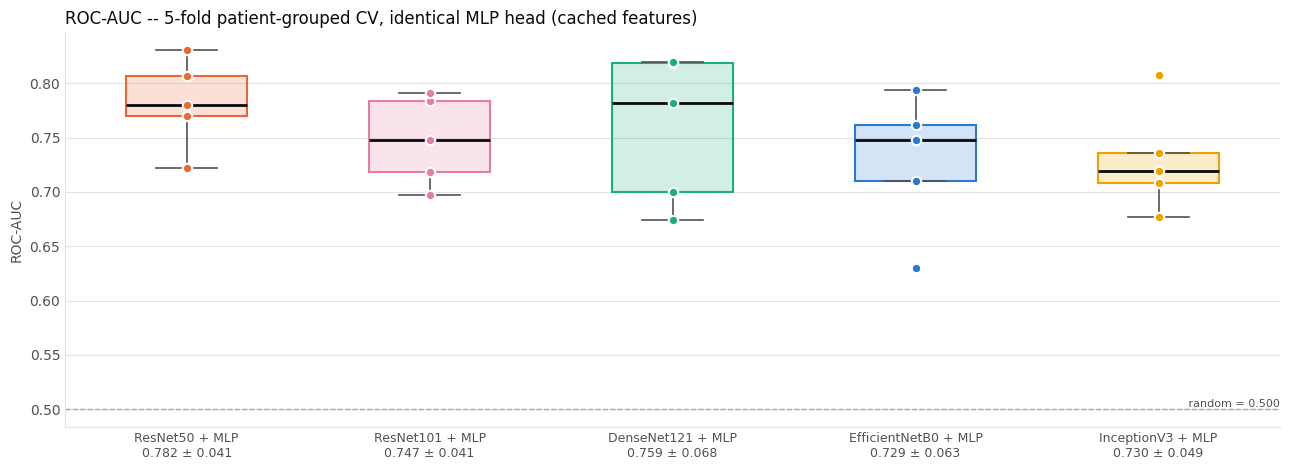

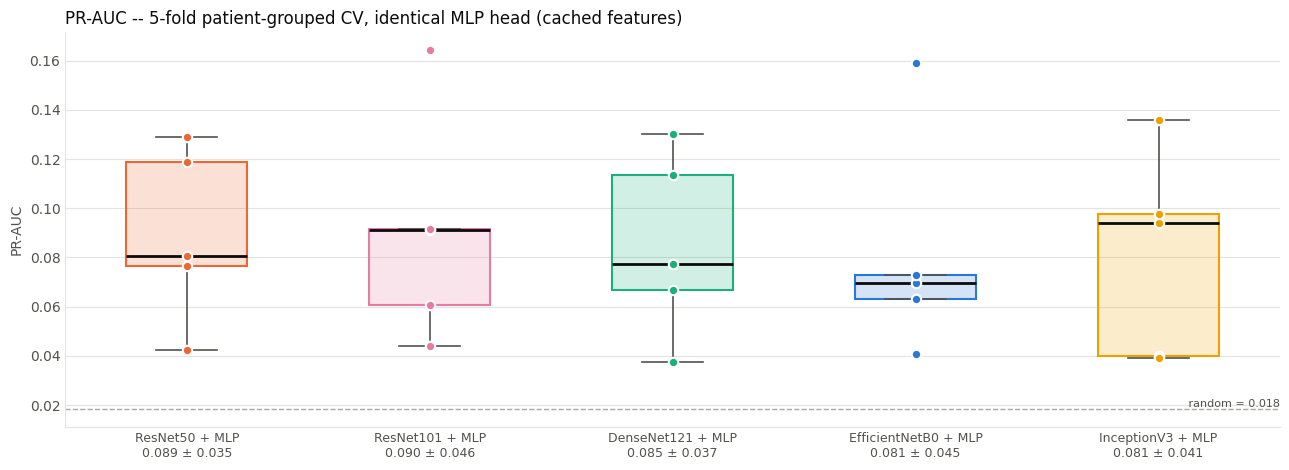

saved figures to cv_mlp_backbones_fast_figures/


In [15]:
MODEL_COLORS = {'ResNet50 + MLP': '#eb6834', 'ResNet101 + MLP': '#e87ba4', 'DenseNet121 + MLP': '#1baf7a',
                'EfficientNetB0 + MLP': '#2a78d6', 'InceptionV3 + MLP': '#eda100'}
INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
FIG_DIR = 'cv_mlp_backbones_fast_figures'
os.makedirs(FIG_DIR, exist_ok=True)

for metric, label, baseline in [('roc_auc', 'ROC-AUC', 0.5), ('pr_auc', 'PR-AUC', y.mean())]:
    values = [results.loc[results['model'] == m, metric].to_numpy() for m in MODEL_ORDER]
    fig, ax = plt.subplots(figsize=(2.3 * len(MODEL_ORDER) + 1.5, 4.8))
    bp = ax.boxplot(values, positions=range(len(MODEL_ORDER)), widths=0.5, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=INK_MUTED, linewidth=1.2),
                    capprops=dict(color=INK_MUTED, linewidth=1.2), boxprops=dict(linewidth=1.5))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m] + '33')
        patch.set_edgecolor(MODEL_COLORS[m])
    for pos, (vals, m) in enumerate(zip(values, MODEL_ORDER)):
        ax.scatter(np.full(len(vals), pos), vals, s=46, color=MODEL_COLORS[m], edgecolor='white',
                   linewidth=1.5, zorder=3)
    ax.axhline(baseline, color='#a8a7a0', linestyle='--', linewidth=1)
    ax.text(len(MODEL_ORDER) - 0.5, baseline, f' random = {baseline:.3f}', va='bottom', ha='right',
            fontsize=8, color=INK_MUTED)
    ax.set_xticks(range(len(MODEL_ORDER)),
                  [f'{m}\n{v.mean():.3f} ± {v.std(ddof=1):.3f}' for m, v in zip(MODEL_ORDER, values)],
                  fontsize=9, color=INK)
    ax.set_ylabel(label, color=INK_MUTED)
    ax.set_title(f'{label} -- {N_FOLDS}-fold patient-grouped CV, identical MLP head (cached features)',
                 color=INK, fontsize=12, loc='left')
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'cv_mlp_backbones_fast_{metric}.png'), dpi=200, bbox_inches='tight',
                facecolor='white')
    plt.show()

if os.path.isdir(DRIVE_DIR):
    shutil.copytree(FIG_DIR, os.path.join(DRIVE_DIR, FIG_DIR), dirs_exist_ok=True)
    shutil.copy('cv_mlp_backbones_fast_summary.csv', os.path.join(DRIVE_DIR, 'cv_mlp_backbones_fast_summary.csv'))
print(f'saved figures to {FIG_DIR}/')

## Equal-budget head tuning per backbone

The comparison above gives every backbone the **same** head -- one that was originally tuned for ResNet50. Here
every backbone gets the **same tuning budget** instead, so each is compared at its own best head.

1. **One grid, used for every backbone** (24 head configs; hidden-layer dropout stays 0.6 / 0.4):

   | Setting | Values |
   |---|---|
   | hidden layers | [128, 32], [256, 64] |
   | input dropout | 0.2, 0.4 |
   | L2 | 1e-4, 1e-3, 1e-2 |
   | learning rate | 5e-4, 1e-3 |

2. **Every config × backbone × fold** trains exactly like above (fit split + fresh pool draw each epoch, early
   stopping on the early-stop split), from the cached features -- nothing goes through a backbone again.
   5 backbones × 24 configs × 5 folds = 600 short runs.
3. **Each backbone's config is chosen by its mean early-stop-split AUC** across the 5 folds. The held-out folds are
   recorded but **never used to choose**.
4. **Reported:** each backbone's held-out ROC-AUC / PR-AUC at its own chosen config, next to the identical-head
   results above.

Results are saved after every (backbone, config) to `cv_mlp_backbones_tuning_results.csv` (and Drive); re-running
skips anything already done. Roughly 1-2 hours on Colab for the full grid.

In [16]:
import itertools
import json

TUNING_GRID = {
    'hidden_units': [[128, 32], [256, 64]],
    'input_dropout': [0.2, 0.4],
    'l2': [1e-4, 1e-3, 1e-2],
    'learning_rate': [5e-4, 1e-3],
}
TUNING_HIDDEN_DROPOUT = [0.6, 0.4]       # fixed -- one rate per hidden layer
TUNING_MODELS = list(BACKBONES)
TUNING_CSV = 'cv_mlp_backbones_tuning_results.csv'

tuning_configs = [dict(zip(TUNING_GRID, v)) for v in itertools.product(*TUNING_GRID.values())]
config_key = lambda cfg: json.dumps(cfg, sort_keys=True)
print(f'{len(tuning_configs)} configs x {len(TUNING_MODELS)} backbones x {N_FOLDS} folds '
      f'= {len(tuning_configs) * len(TUNING_MODELS) * N_FOLDS} training runs')


def build_head_cfg(feature_dim, cfg):
    reg = lambda: tf.keras.regularizers.l2(cfg['l2'])
    inputs = tf.keras.Input(shape=(feature_dim,))
    x = layers.Dropout(cfg['input_dropout'])(inputs)
    for units, rate in zip(cfg['hidden_units'], TUNING_HIDDEN_DROPOUT):
        x = layers.Dense(units, activation='relu', kernel_regularizer=reg())(x)
        x = layers.Dropout(rate)(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=reg())(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['learning_rate']), loss='binary_crossentropy')
    return model


def train_fold_cfg(F, F_pool, f, seed, cfg):
    # Same procedure as train_fold above -- only the head / learning rate come from cfg
    rng = np.random.default_rng(seed)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    fit_idx, stop_idx = f['fit'], f['stop']
    fit_mal_idx = fit_idx[y[fit_idx] == 1]
    n_extra = n_extra_copies(y[fit_idx])
    class_weight = blended_class_weight(y[fit_idx])
    model = build_head_cfg(F.shape[1], cfg)

    best_auc, best_epoch, best_weights, wait = -np.inf, 0, None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        F_epoch = np.concatenate([F[fit_idx], sample_augmented(F_pool, fit_mal_idx, n_extra, rng)])
        y_epoch = np.concatenate([y[fit_idx], np.ones(n_extra, dtype=int)])
        model.fit(F_epoch, y_epoch, batch_size=BATCH_SIZE, epochs=1, shuffle=True,
                  class_weight=class_weight, verbose=0)
        stop_auc = roc_auc_score(y[stop_idx], model.predict(F[stop_idx], verbose=0).ravel())
        if stop_auc > best_auc:
            best_auc, best_epoch, best_weights, wait = stop_auc, epoch, model.get_weights(), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.set_weights(best_weights)
    return model, best_epoch, best_auc


tuning = load_csv(TUNING_CSV)
done = set(zip(tuning['model'], tuning['config'])) if len(tuning) else set()
todo = [(m, cfg) for m in TUNING_MODELS for cfg in tuning_configs if (m, config_key(cfg)) not in done]
print(f'{len(done)} (backbone, config) pairs already done, {len(todo)} to run')

t_start = time.time()
for n, (model_name, cfg) in enumerate(todo, start=1):
    F, F_pool = features[model_name]['features'], features[model_name]['pool']
    rows = []
    for f in folds:
        model, best_epoch, stop_auc = train_fold_cfg(F, F_pool, f, SEED + f['fold'], cfg)
        y_va = y[f['val']]
        prob = model.predict(F[f['val']], verbose=0).ravel()
        rows.append({'model': model_name, 'config': config_key(cfg), **{k: str(v) for k, v in cfg.items()},
                     'fold': f['fold'], 'early_stop_auc': stop_auc, 'best_epoch': best_epoch,
                     'roc_auc': roc_auc_score(y_va, prob), 'pr_auc': average_precision_score(y_va, prob)})
    tuning = pd.concat([tuning, pd.DataFrame(rows)], ignore_index=True)
    save_csv(tuning, TUNING_CSV)      # saved per (backbone, config), so a disconnect loses at most one
    mean_stop = np.mean([r['early_stop_auc'] for r in rows])
    elapsed = (time.time() - t_start) / 60
    print(f'[{n}/{len(todo)}] {model_name:22s} {cfg} -> early-stop AUC {mean_stop:.4f} '
          f'({elapsed:.0f} min elapsed, ~{elapsed / n * (len(todo) - n):.0f} min left)')

24 configs x 5 backbones x 5 folds = 600 training runs
98 (backbone, config) pairs already done, 22 to run
[1/22] InceptionV3 + MLP      {'hidden_units': [128, 32], 'input_dropout': 0.2, 'l2': 0.001, 'learning_rate': 0.0005} -> early-stop AUC 0.7728 (1 min elapsed, ~22 min left)
[2/22] InceptionV3 + MLP      {'hidden_units': [128, 32], 'input_dropout': 0.2, 'l2': 0.001, 'learning_rate': 0.001} -> early-stop AUC 0.7647 (2 min elapsed, ~18 min left)
[3/22] InceptionV3 + MLP      {'hidden_units': [128, 32], 'input_dropout': 0.2, 'l2': 0.01, 'learning_rate': 0.0005} -> early-stop AUC 0.7601 (3 min elapsed, ~18 min left)
[4/22] InceptionV3 + MLP      {'hidden_units': [128, 32], 'input_dropout': 0.2, 'l2': 0.01, 'learning_rate': 0.001} -> early-stop AUC 0.7607 (4 min elapsed, ~17 min left)
[5/22] InceptionV3 + MLP      {'hidden_units': [128, 32], 'input_dropout': 0.4, 'l2': 0.0001, 'learning_rate': 0.0005} -> early-stop AUC 0.7679 (5 min elapsed, ~16 min left)
[6/22] InceptionV3 + MLP      {

### Each backbone at its own best head

For every backbone: the config with the highest **mean early-stop-split AUC** across the 5 folds (ties broken by the
smaller head / stronger regularisation, i.e. the first in grid order). Then its **held-out** ROC-AUC and PR-AUC,
next to the identical-head results from above.

The early-stop AUC column is what the choice was based on; it's slightly optimistic (it's the best of 24 on that
split). The held-out columns are the honest numbers to report.

In [17]:
tuning = load_csv(TUNING_CSV)
tuning = tuning[tuning['config'].isin({config_key(c) for c in tuning_configs})]   # current grid only
complete = tuning.groupby(['model', 'config'])['fold'].count().reset_index()
assert (complete['fold'] == N_FOLDS).all(), 'some (backbone, config) pairs are missing folds'

per_config = (tuning.groupby(['model', 'config'], sort=False)
              .agg(early_stop_auc=('early_stop_auc', 'mean'), roc_auc=('roc_auc', 'mean'), roc_std=('roc_auc', 'std'),
                   pr_auc=('pr_auc', 'mean'), pr_std=('pr_auc', 'std'))
              .reset_index())
best_rows = per_config.loc[per_config.groupby('model')['early_stop_auc'].idxmax()].set_index('model')

identical = load_csv(RESULTS_CSV).groupby('model').agg(roc=('roc_auc', 'mean'), roc_sd=('roc_auc', 'std'),
                                                       pr=('pr_auc', 'mean'), pr_sd=('pr_auc', 'std'))
TUNED_ORDER = [m for m in BACKBONES if m in best_rows.index]
tuned_summary = pd.DataFrame({
    'chosen config': [json.loads(best_rows.loc[m, 'config']) for m in TUNED_ORDER],
    'early-stop AUC (choice)': [f"{best_rows.loc[m, 'early_stop_auc']:.3f}" for m in TUNED_ORDER],
    'tuned: CV ROC-AUC': [f"{best_rows.loc[m, 'roc_auc']:.3f} ± {best_rows.loc[m, 'roc_std']:.3f}" for m in TUNED_ORDER],
    'tuned: CV PR-AUC': [f"{best_rows.loc[m, 'pr_auc']:.3f} ± {best_rows.loc[m, 'pr_std']:.3f}" for m in TUNED_ORDER],
    'identical head: CV ROC-AUC': [f"{identical.loc[m, 'roc']:.3f} ± {identical.loc[m, 'roc_sd']:.3f}"
                                   if m in identical.index else '' for m in TUNED_ORDER],
    'identical head: CV PR-AUC': [f"{identical.loc[m, 'pr']:.3f} ± {identical.loc[m, 'pr_sd']:.3f}"
                                  if m in identical.index else '' for m in TUNED_ORDER],
}, index=TUNED_ORDER)
pd.set_option('display.max_colwidth', None)
display(tuned_summary)

# Per-fold held-out results of each backbone's chosen config (paired across backbones)
chosen = tuning.merge(best_rows[['config']].reset_index(), on=['model', 'config'])
tuned_roc_wide = chosen.pivot(index='fold', columns='model', values='roc_auc')[TUNED_ORDER]
display(tuned_roc_wide.round(3).rename(columns=lambda m: f'{m} ROC'))
print('folds won (highest held-out ROC-AUC, tuned heads):', tuned_roc_wide.idxmax(axis=1).value_counts().to_dict())

# How much the choice of head matters for each backbone: spread of held-out ROC-AUC across the 24 configs
spread = per_config.groupby('model')['roc_auc'].agg(['min', 'median', 'max']).reindex(TUNED_ORDER).round(3)
display(spread.rename(columns=lambda c: f'held-out ROC-AUC across configs: {c}'))

tuned_summary.to_csv('cv_mlp_backbones_tuned_summary.csv')
if os.path.isdir(DRIVE_DIR):
    shutil.copy('cv_mlp_backbones_tuned_summary.csv', os.path.join(DRIVE_DIR, 'cv_mlp_backbones_tuned_summary.csv'))

,chosen config,early-stop AUC (choice),tuned: CV ROC-AUC,tuned: CV PR-AUC,identical head: CV ROC-AUC,identical head: CV PR-AUC
ResNet50 + MLP,"{'hidden_units': [256, 64], 'input_dropout': 0.4, 'l2': 0.01, 'learning_rate': 0.001}",0.850,0.796 ± 0.043,0.094 ± 0.038,0.782 ± 0.041,0.089 ± 0.035
ResNet101 + MLP,"{'hidden_units': [256, 64], 'input_dropout': 0.4, 'l2': 0.01, 'learning_rate': 0.001}",0.816,0.774 ± 0.067,0.099 ± 0.035,0.747 ± 0.041,0.090 ± 0.046
DenseNet121 + MLP,"{'hidden_units': [256, 64], 'input_dropout': 0.2, 'l2': 0.001, 'learning_rate': 0.0005}",0.811,0.749 ± 0.071,0.083 ± 0.033,0.759 ± 0.068,0.085 ± 0.037
EfficientNetB0 + MLP,"{'hidden_units': [256, 64], 'input_dropout': 0.2, 'l2': 0.001, 'learning_rate': 0.0005}",0.787,0.726 ± 0.062,0.085 ± 0.039,0.729 ± 0.063,0.081 ± 0.045
InceptionV3 + MLP,"{'hidden_units': [256, 64], 'input_dropout': 0.2, 'l2': 0.0001, 'learning_rate': 0.0005}",0.779,0.735 ± 0.049,0.071 ± 0.034,0.730 ± 0.049,0.081 ± 0.041


model,ResNet50 + MLP ROC,ResNet101 + MLP ROC,DenseNet121 + MLP ROC,EfficientNetB0 + MLP ROC,InceptionV3 + MLP ROC
fold,,,,,
1,0.819,0.816,0.775,0.742,0.815
2,0.745,0.691,0.662,0.619,0.681
3,0.808,0.806,0.787,0.738,0.714
4,0.759,0.715,0.689,0.762,0.729
5,0.847,0.843,0.832,0.771,0.737


folds won (highest held-out ROC-AUC, tuned heads): {'ResNet50 + MLP': 4, 'EfficientNetB0 + MLP': 1}


,held-out ROC-AUC across configs: min,held-out ROC-AUC across configs: median,held-out ROC-AUC across configs: max
model,,,
ResNet50 + MLP,0.775,0.786,0.800
ResNet101 + MLP,0.747,0.775,0.788
DenseNet121 + MLP,0.742,0.751,0.766
EfficientNetB0 + MLP,0.705,0.727,0.736
InceptionV3 + MLP,0.718,0.732,0.757


### Boxplots: tuned heads

Same layout as above, each backbone at its own chosen config. Saved to `cv_mlp_backbones_fast_figures/` as
`cv_mlp_backbones_tuned_<metric>.png` (and Drive).

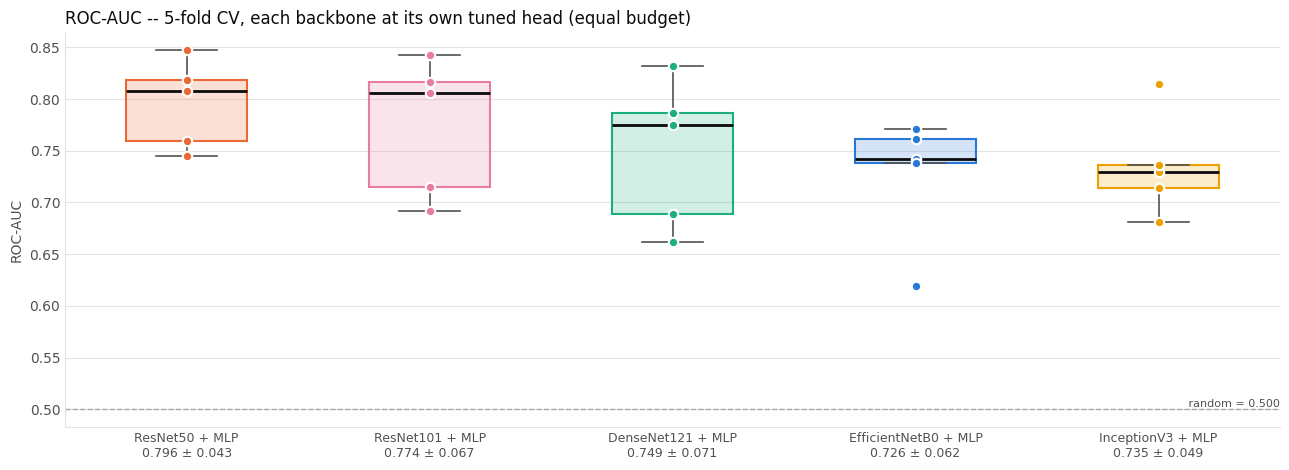

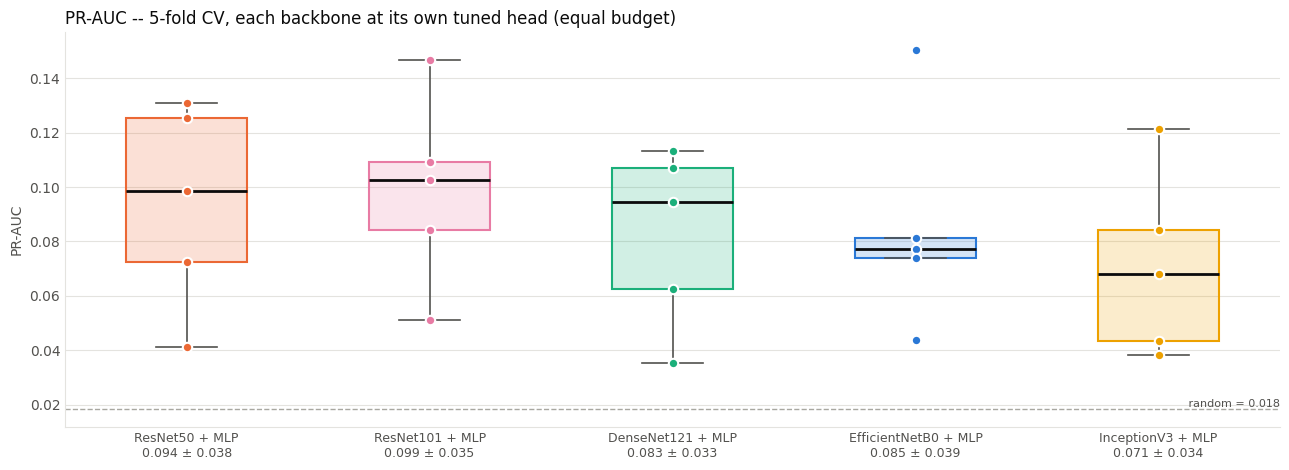

In [18]:
for metric, label, baseline in [('roc_auc', 'ROC-AUC', 0.5), ('pr_auc', 'PR-AUC', y.mean())]:
    values = [chosen.loc[chosen['model'] == m, metric].to_numpy() for m in TUNED_ORDER]
    fig, ax = plt.subplots(figsize=(2.3 * len(TUNED_ORDER) + 1.5, 4.8))
    bp = ax.boxplot(values, positions=range(len(TUNED_ORDER)), widths=0.5, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=INK_MUTED, linewidth=1.2),
                    capprops=dict(color=INK_MUTED, linewidth=1.2), boxprops=dict(linewidth=1.5))
    for patch, m in zip(bp['boxes'], TUNED_ORDER):
        patch.set_facecolor(MODEL_COLORS[m] + '33')
        patch.set_edgecolor(MODEL_COLORS[m])
    for pos, (vals, m) in enumerate(zip(values, TUNED_ORDER)):
        ax.scatter(np.full(len(vals), pos), vals, s=46, color=MODEL_COLORS[m], edgecolor='white',
                   linewidth=1.5, zorder=3)
    ax.axhline(baseline, color='#a8a7a0', linestyle='--', linewidth=1)
    ax.text(len(TUNED_ORDER) - 0.5, baseline, f' random = {baseline:.3f}', va='bottom', ha='right',
            fontsize=8, color=INK_MUTED)
    ax.set_xticks(range(len(TUNED_ORDER)),
                  [f'{m}\n{v.mean():.3f} ± {v.std(ddof=1):.3f}' for m, v in zip(TUNED_ORDER, values)],
                  fontsize=9, color=INK)
    ax.set_ylabel(label, color=INK_MUTED)
    ax.set_title(f'{label} -- {N_FOLDS}-fold CV, each backbone at its own tuned head (equal budget)',
                 color=INK, fontsize=12, loc='left')
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'cv_mlp_backbones_tuned_{metric}.png'), dpi=200, bbox_inches='tight',
                facecolor='white')
    plt.show()

if os.path.isdir(DRIVE_DIR):
    shutil.copytree(FIG_DIR, os.path.join(DRIVE_DIR, FIG_DIR), dirs_exist_ok=True)